In [11]:
import os
from gudhi import RipsComplex
import numpy as np
from collections import defaultdict
from typing import Dict, List, Tuple, Optional, Set, Callable

import matplotlib.pyplot as plt
from gudhi.representations import PersistenceImage
from scipy.stats import norm
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from persim import PersistenceImager
import persim.images_weights as weights

In [14]:
def visualize_PIs(PIs, max_eps=10, px_res=0.1):
    import matplotlib.pyplot as plt
    
    # H0: shape (100,) - 1D image
    # 논문에서 mean(axis=0)으로 1D가 되었으므로 그대로 plot
    h0_img = PIs[0]
    h0_length = int(max_eps / px_res)  # 100
    
    # H1: shape (5000,) → reshape to (100, 50)
    h1_birth_bins = int(max_eps / px_res)  # 100
    h1_pers_bins = int((max_eps / 2) / px_res)  # 50
    h1_img = PIs[1].reshape((h1_birth_bins, h1_pers_bins))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # H0 (1D plot)
    axes[0].plot(h0_img, 'b-', linewidth=1.5)
    axes[0].fill_between(range(len(h0_img)), h0_img, alpha=0.3)
    axes[0].set_title(f'H0 Persistence Image (1D)\nLength: {h0_length}')
    axes[0].set_xlabel('Persistence (Bin Index)')
    axes[0].set_ylabel('Intensity')
    axes[0].set_xlim([0, h0_length])
    axes[0].grid(True, alpha=0.3)
    
    # H1 (2D image)
    im = axes[1].imshow(h1_img.T, cmap='hot', origin='lower', aspect='auto')
    axes[1].set_title(f'H1 Persistence Image (2D)\nResolution: ({h1_birth_bins}, {h1_pers_bins})')
    axes[1].set_xlabel('Birth (Bin Index)')
    axes[1].set_ylabel('Persistence (Bin Index)')
    plt.colorbar(im, ax=axes[1], label='Intensity')
    
    plt.tight_layout()
    plt.show()

In [2]:
def compute_Rips(points, max_edge=10, max_dim=2):
    """Compute Rips complex with perturbation for unique filtration values."""
    rips = RipsComplex(points=points, max_edge_length=max_edge)
    st = rips.create_simplex_tree(max_dimension=max_dim)

    return st


def extract_filtration(st):
    """Extract simplices and filtration values from simplex tree."""
    pairs = [(tuple(sorted(s)), f) for s, f in st.get_filtration()]
    simplices = [p[0] for p in pairs]
    filt_values = [p[1] for p in pairs]
    return simplices, filt_values


def _reduce_matrix(columns, n):
    """
    Standard column reduction algorithm (Algorithm 1 in paper).
    Returns reduced matrix R and low array (pivot positions).
    """
    R = [set(col) for col in columns]
    low = [-1] * n
    pivot_to_col = {}
    
    for j in range(n):
        while R[j]:
            pivot = max(R[j])
            if pivot in pivot_to_col:
                R[j] ^= R[pivot_to_col[pivot]]
            else:
                pivot_to_col[pivot] = j
                low[j] = pivot
                break
        else:
            low[j] = -1
    
    return R, low


In [3]:
# =============================================================================
# Main Algorithm: Mixup Barcode (Algorithm 2 - Exact Implementation)
# =============================================================================

def compute_mixup_barcode(A: np.ndarray, B: np.ndarray, max_edge: float = 10, max_dim: int = 1) -> Dict:
    """
    Compute mixup barcode for inclusion L ↪ K where:
    - L = VR(A) (Vietoris-Rips filtration on A)  
    - K = VR(A ∪ B) (Vietoris-Rips filtration on A ∪ B)
    
    Implements Algorithm 2 from Wagner et al. (2024) exactly.
    
    Args:
        A: Point cloud defining subcomplex L
        B: Additional points (K = VR(A ∪ B))
        max_edge: Maximum edge length for Rips complex
        max_dim: Maximum homology dimension to compute (default 1)
    
    Returns:
        Dictionary with keys 0, 1, ... for each homology dimension.
        Each value is np.array of shape (n, 3) with columns [birth, image_death, domain_death]
    """
    total = np.concatenate([A, B], axis=0)
    a = len(A)  # Number of points in A
    
    # Build Rips complex on total space K = VR(A ∪ B)
    st = compute_Rips(total, max_edge, max_dim=max_dim+1)
    simplices, filt = extract_filtration(st)
    n = len(simplices)
    
    # Get simplex dimensions
    simplex_dims = [len(s) - 1 for s in simplices]
    
    # Create simplex to index mapping
    sf_to_idx = {s: i for i, s in enumerate(simplices)}
    
    # Identify which simplices are in L (all vertices in A)
    in_L = [all(v < a for v in s) for s in simplices]
    idx_L = [i for i, b in enumerate(in_L) if b]      # indices of L simplices
    idx_KmL = [i for i, b in enumerate(in_L) if not b]  # indices of K\L simplices
    set_L = set(idx_L)
    
    # ==========================================================
    # Step 1: Build BK - boundary matrix with columns containing
    # the boundaries of k- and (k+1)-simplices of K
    # Rows and columns ordered by filtration index
    # ==========================================================
    BK_original = []
    for s in simplices:
        if len(s) <= 1:
            BK_original.append(set())
        else:
            rows = set()
            for j in range(len(s)):
                face = s[:j] + s[j+1:]
                if face in sf_to_idx:
                    rows.add(sf_to_idx[face])
            BK_original.append(rows)
    
    # ==========================================================
    # Step 2: Reorder the ROWS of BK such that simplices from L
    # have smaller indices than simplices of K\L, while retaining
    # the relative order within L and within K\L
    # ==========================================================
    row_order = idx_L + idx_KmL  # New row ordering: L first, then K\L
    old_to_new_row = {old: new for new, old in enumerate(row_order)}
    new_to_old_row = {new: old for old, new in old_to_new_row.items()}
    n_L = len(idx_L)
    
    # Apply row reordering to BK
    BK = []
    for col_idx in range(n):
        new_rows = {old_to_new_row[r] for r in BK_original[col_idx]}
        BK.append(new_rows)
    
    # ==========================================================
    # Step 3: Form matrix BL by zeroing out the entries in BK
    # involving ONLY the simplices of K\L
    # 
    # Key insight from paper: BL has the same rows/columns as BK,
    # but entries are zeroed if they involve K\L simplices
    # ==========================================================
    BL = []
    for col_idx in range(n):
        if in_L[col_idx]:
            # Column is in L: keep only rows that correspond to L simplices
            # (rows with new index < n_L)
            new_rows = {r for r in BK[col_idx] if r < n_L}
            BL.append(new_rows)
        else:
            # Column is in K\L: zero out entirely
            BL.append(set())
    
    # ==========================================================
    # Step 4: Reduce BL and BK using Algorithm 1
    # ==========================================================
    RL, lowL = _reduce_matrix(BL, n)
    RK, lowK = _reduce_matrix(BK, n)
    
    # Build reverse lookup: (reordered) pivot row -> column index
    # For BL: only care about columns in L
    pivotL_to_col = {}
    for j in idx_L:  # Only columns in L can give domain death
        if lowL[j] != -1:
            pivotL_to_col[lowL[j]] = j
    
    # For BK: any column can give image death
    pivotK_to_col = {}
    for j in range(n):
        if lowK[j] != -1:
            pivotK_to_col[lowK[j]] = j
    
    # ==========================================================
    # Step 5: Extract mixup triples
    # For each index σ of a k-simplex in L such that BL[σ] = 0:
    #   - σ gives birth to a homology class
    #   - Find τ such that pivot(BL[τ]) = σ (domain death)
    #   - Find τ' such that pivot(BK[τ']) = σ (image death)
    #   - Record (f(σ), f(τ'), f(τ))
    # ==========================================================
    mixup_triples = defaultdict(list)
    
    for sigma in idx_L:
        # Check: RL[sigma] should be empty (σ is positive in L)
        if RL[sigma]:
            continue
        
        dim = simplex_dims[sigma]
        if dim > max_dim:
            continue
        
        # σ's row index after reordering
        sigma_row = old_to_new_row[sigma]
        
        birth = filt[sigma]
        
        # Find τ: column in L such that pivot(RL[τ]) = sigma_row (domain death)
        tau = pivotL_to_col.get(sigma_row, None)
        if tau is not None:
            death = filt[tau]
        else:
            death = np.inf
        
        # Find τ': column such that pivot(RK[τ']) = sigma_row (image death)
        tau_prime = pivotK_to_col.get(sigma_row, None)
        if tau_prime is not None:
            death_prime = filt[tau_prime]
        else:
            death_prime = np.inf
        
        # Sanity check: image death ≤ domain death (from Observation 2)
        if not np.isinf(death) and (np.isinf(death_prime) or death_prime > death):
            death_prime = death
        
        # Record non-trivial bars
        if np.isinf(death) or abs(death - birth) > 1e-10:
            mixup_triples[dim].append((birth, death_prime, death))
    
    # ==========================================================
    # Format output
    # ==========================================================
    result = {}
    for dim in sorted(mixup_triples.keys()):
        triples = mixup_triples[dim]
        if triples:
            arr = np.array(triples)
            order = np.argsort(arr[:, 0])
            result[dim] = arr[order]
        else:
            result[dim] = np.empty((0, 3))
    
    for d in range(max_dim + 1):
        if d not in result:
            result[d] = np.empty((0, 3))
    
    return result

In [4]:
A = np.random.rand(120, 2)*20
B = np.random.rand(80, 2)*20

In [5]:
mixup_barcode_A_to_total = compute_mixup_barcode(A, B)
mixup_barcode_B_to_total = compute_mixup_barcode(B, A)

In [7]:
#Interaction PIs

In [12]:
def compute_Interaction_PIs(
    barcodes,
    max_eps=10,
    px_res=0.1,
    sigma=0.05,
    normalization=False
):
    """
    barcodes[h]: array of shape (N, 3) with (b, d', d)
    - PI 좌표: (b, d-b)
    - weight: d - d'
    - inf 포함 bar는 무시
    """

    vector = {}

    # -------------------------------------------------------------------------
    # 공통: mixup weight 함수 생성기
    # -------------------------------------------------------------------------
    def make_mixup_weight(mixup_weights):
        def weight(birth, persistence, **kwargs):
            # PersistenceImager는 birth, persistence, **weight_params로 호출함
            return mixup_weights
        return weight

    # =========================================================================
    # H0 Persistence Image
    # =========================================================================
    pers_imager_h0 = PersistenceImager()
    pers_imager_h0.pixel_size = px_res
    pers_imager_h0.birth_range = (0, 0.01)
    pers_imager_h0.pers_range = (0, max_eps)
    pers_imager_h0.kernel_params = {'sigma': [[sigma, 0], [0, sigma]]}

    bars_h0 = np.asarray(barcodes.get(0, np.zeros((0, 3))))

    if len(bars_h0) > 0:
        b = bars_h0[:, 0]
        d_prime = bars_h0[:, 1]
        d = bars_h0[:, 2]

        # inf 제거
        mask = np.isfinite(b) & np.isfinite(d_prime) & np.isfinite(d)
        b, d_prime, d = b[mask], d_prime[mask], d[mask]

        if len(b) > 0:
            bars_for_pi = np.stack([b, d], axis=1)
            mixup_weights = d - d_prime

            pers_imager_h0.weight = make_mixup_weight(mixup_weights)
            img_h0 = pers_imager_h0.transform(bars_for_pi, skew=True)
        else:
            img_h0 = np.zeros((int(1 / px_res), int(max_eps / px_res)))
    else:
        img_h0 = np.zeros((int(1 / px_res), int(max_eps / px_res)))

    # 논문 방식: birth 축 평균 → 1D
    img0_1d = np.mean(img_h0, axis=0)

    # =========================================================================
    # H1 Persistence Image
    # =========================================================================
    pers_imager_h1 = PersistenceImager()
    pers_imager_h1.pixel_size = px_res
    pers_imager_h1.birth_range = (0, max_eps)
    pers_imager_h1.pers_range = (0, max_eps / 2)
    pers_imager_h1.kernel_params = {'sigma': [[sigma, 0], [0, sigma]]}

    bars_h1 = np.asarray(barcodes.get(1, np.zeros((0, 3))))

    if len(bars_h1) > 0:
        b = bars_h1[:, 0]
        d_prime = bars_h1[:, 1]
        d = bars_h1[:, 2]

        # inf 제거
        mask = np.isfinite(b) & np.isfinite(d_prime) & np.isfinite(d)
        b, d_prime, d = b[mask], d_prime[mask], d[mask]

        if len(b) > 0:
            bars_for_pi = np.stack([b, d], axis=1)
            mixup_weights = d - d_prime

            pers_imager_h1.weight = make_mixup_weight(mixup_weights)
            img_h1 = pers_imager_h1.transform(bars_for_pi, skew=True)
        else:
            img_h1 = np.zeros(
                (int(max_eps / px_res), int((max_eps / 2) / px_res))
            )
    else:
        img_h1 = np.zeros(
            (int(max_eps / px_res), int((max_eps / 2) / px_res))
        )

    # =========================================================================
    # Normalization & Output
    # =========================================================================
    if normalization:
        vector[0] = img0_1d / np.max(img0_1d) if np.max(img0_1d) > 0 else img0_1d
        vector[1] = (
            img_h1.flatten() / np.max(img_h1)
            if np.max(img_h1) > 0
            else img_h1.flatten()
        )
    else:
        vector[0] = img0_1d
        vector[1] = img_h1.flatten()

    return vector


In [ ]:
inter_PI_A_to_total = compute_Interaction_PIs(mixup_barcode_A_to_total)
inter_PI_B_to_total = compute_Interaction_PIs(mixup_barcode_B_to_total)

'''
여기를 저장
'''

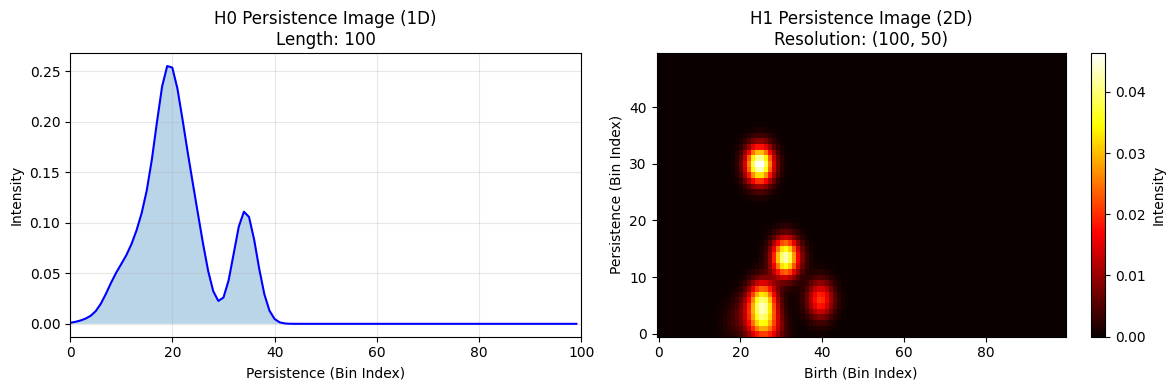

In [20]:
visualize_PIs(inter_PI_A_to_total)

In [16]:
#3D PIs

In [17]:
#3D Persistence Image
def mixup_barcode_translation(
    mixup_barcode: Dict[int, List[np.ndarray]]
) -> Dict[int, List[List[float]]]:
   
    translation = {}
    for i in range(2):
        translated_mixup_barcode = []
        for bar in mixup_barcode[i]:
            # [birth, death - birth, extra_coord - birth]
            translated_bar = [bar[0], bar[1] - bar[0], bar[2] - bar[0]]
            translated_mixup_barcode.append(translated_bar)
        translation[i] = translated_mixup_barcode
    return translation


def compute_3d_persistence_image(
    mixup_barcodes,
    resolution: int = 20,
    ranges=((0, 10), (0, 10), (0, 10)),
    bandwidth: float = 0.1,
    weight_func=None,
    normalization: bool = False
):
    """
    H0 → 2D PI → flatten → (resolution^2,)
    H1 → 3D PI → flatten → (resolution^3,)
    """

    translated = mixup_barcode_translation(mixup_barcodes)
    persistence_vectors = {}

    if weight_func is None:
        weight_func = lambda p: 1.0

    x_grid = np.linspace(ranges[0][0], ranges[0][1], resolution)
    y_grid = np.linspace(ranges[1][0], ranges[1][1], resolution)
    z_grid = np.linspace(ranges[2][0], ranges[2][1], resolution)

    for i in range(2):
        barcode = translated[i]

        if i == 0:
            persistence_image = np.zeros((resolution, resolution))

            for point in barcode:
                # point = [b, p1, p2], b ≡ 0
                w = weight_func(point)

                gy = norm.pdf(y_grid, loc=point[1], scale=bandwidth)
                gz = norm.pdf(z_grid, loc=point[2], scale=bandwidth)

                gaussian_2d = np.outer(gy, gz)
                persistence_image += w * gaussian_2d

        else:
            persistence_image = np.zeros((resolution, resolution, resolution))

            for point in barcode:
                w = weight_func(point)

                gx = norm.pdf(x_grid, loc=point[0], scale=bandwidth)
                gy = norm.pdf(y_grid, loc=point[1], scale=bandwidth)
                gz = norm.pdf(z_grid, loc=point[2], scale=bandwidth)

                gaussian_3d = np.einsum('i,j,k->ijk', gx, gy, gz)
                persistence_image += w * gaussian_3d

        if normalization:
            max_val = np.max(persistence_image)
            if max_val > 0:
                persistence_image = persistence_image.flatten() / max_val

    
        persistence_vectors[i] = persistence_image.flatten()

    return persistence_vectors

In [18]:
def visualize_3d_PIs(
    PIs,
    resolution=20,
    ranges=((0, 10), (0, 10), (0, 10)),
    h0_cmap='hot'
):
    """
    PIs[0]: flattened H0 PI  -> (res^2,)
    PIs[1]: flattened H1 PI  -> (res^3,)
    """

    # ============================================================
    # H0: 2D Persistence Image
    # ============================================================
    h0_img = PIs[0].reshape((resolution, resolution))

    plt.figure(figsize=(5, 4))
    im = plt.imshow(
        h0_img.T,
        origin='lower',
        cmap=h0_cmap,
        aspect='auto'
    )
    plt.colorbar(im, label='Intensity')
    plt.title(f'H0 Persistence Image (2D)\nResolution: {resolution}×{resolution}')
    plt.xlabel('Persistence (death - birth)')
    plt.ylabel('Attribute Diff (extra - birth)')
    plt.tight_layout()
    plt.show()

    # ============================================================
    # H1: 3D Persistence Image (Volume Rendering)
    # ============================================================
    h1_img = PIs[1].reshape((resolution, resolution, resolution))

    # 3D grid
    x, y, z = np.mgrid[
        ranges[0][0]:ranges[0][1]:resolution*1j,
        ranges[1][0]:ranges[1][1]:resolution*1j,
        ranges[2][0]:ranges[2][1]:resolution*1j
    ]

    fig = make_subplots(
        rows=1, cols=1,
        specs=[[{'type': 'volume'}]],
        subplot_titles=('H1 3D Persistence Image',)
    )

    fig.add_trace(go.Volume(
        x=x.flatten(),
        y=y.flatten(),
        z=z.flatten(),
        value=h1_img.flatten(),
        isomin=0.1 * np.max(h1_img),
        isomax=np.max(h1_img),
        opacity=0.1,
        surface_count=20,
        colorscale='Viridis',
        colorbar=dict(title='Density'),
        name='H1'
    ))

    fig.update_layout(
        title_text='H1 3D Persistence Image Visualization',
        scene=dict(
            xaxis_title='Birth',
            yaxis_title='Persistence (death - birth)',
            zaxis_title='Attribute Diff (extra - birth)'
        ),
        height=600,
        width=700
    )

    fig.show()

In [ ]:
PI_3D_A_to_total = compute_3d_persistence_image(
    mixup_barcode_A_to_total,
    resolution=20,
    ranges=((0, 10), (0, 10), (0, 10)),
    bandwidth=0.4
)
PI_3D_B_to_total = compute_3d_persistence_image(
    mixup_barcode_B_to_total,
    resolution=20,
    ranges=((0, 10), (0, 10), (0, 10)),
    bandwidth=0.4
)

'''
여기를 저장
'''

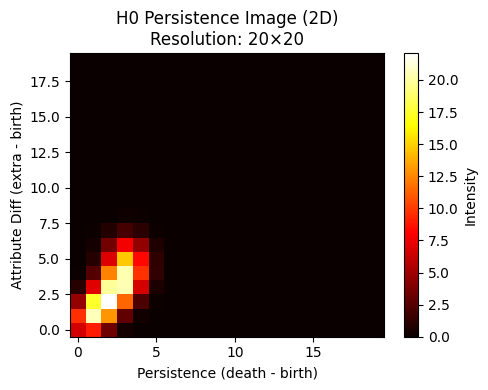

In [23]:
visualize_3d_PIs(PI_3D_B_to_total)